In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Iniciando Benchmark de Ataque de Força Bruta...
Nota: 'Curve25519' aqui usa a equação de Montgomery com A=486662,
      mas sobre corpos pequenos (10-24 bits) para permitir o ataque.

BITS  | RSA (s)    | Weierstrass (s) | Curve25519 (s) 
-------------------------------------------------------
10    | 0.00000    | 0.00005         | 0.00005
12    | 0.00000    | 0.00087         | 0.00061
14    | 0.00000    | 0.00122         | 0.00157
16    | 0.00000    | 0.00876         | 0.00817
18    | 0.00000    | 0.03403         | 0.02779
20    | 0.00000    | 0.24060         | 0.04491
22    | 0.00000    | 0.30634         | 0.13377
24    | 0.00050    | 0.42171         | 2.11226
26    | 0.00010    | 0.48300         | 9.16834
28    | 0.00042    | 0.48715         | 51.12700


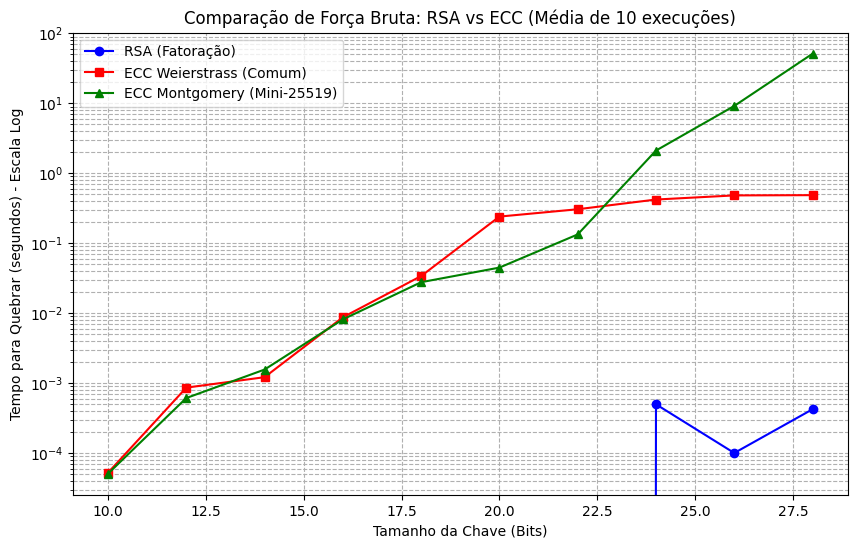

In [4]:
import time
import random
import matplotlib.pyplot as plt
import math

# ==============================================================================
# 1. FUNÇÕES AUXILIARES E RSA
# ==============================================================================

def is_prime(n):
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True

def generate_rsa_key(bits):
    target = 2**(bits // 2)
    def get_prime(target):
        while True:
            p = random.randint(target, 2*target)
            if is_prime(p): return p
    p = get_prime(target)
    q = get_prime(target)
    return p * q

def crack_rsa(n):
    start_time = time.time()
    limit = int(n**0.5) + 1
    for i in range(2, limit):
        if n % i == 0:
            return time.time() - start_time
    return time.time() - start_time

# ==============================================================================
# 2. CURVA WEIERSTRASS (Curva "Comum" - Secp-like)
# Equação: y^2 = x^3 + ax + b (mod p)
# ==============================================================================

class WeierstrassCurve:
    def __init__(self, a, b, p):
        self.a = a
        self.b = b
        self.p = p

    def add(self, p1, p2):
        if p1 is None: return p2
        if p2 is None: return p1
        x1, y1 = p1
        x2, y2 = p2
        
        if x1 == x2 and (y1 + y2) % self.p == 0: return None # P + (-P) = 0
        
        if x1 == x2: # Dobrar
            if y1 == 0: return None
            m = (3 * x1**2 + self.a) * pow(2 * y1, -1, self.p)
        else: # Somar
            m = (y2 - y1) * pow(x2 - x1, -1, self.p)
        
        m = m % self.p
        x3 = (m**2 - x1 - x2) % self.p
        y3 = (m * (x1 - x3) - y1) % self.p
        return (x3, y3)

def gen_weierstrass(bits):
    while True:
        p = random.randint(2**(bits-1), 2**bits)
        if is_prime(p) and p % 4 == 3: break # p=3 mod 4 facilita raiz quadrada
    
    a, b = 2, 3 
    curve = WeierstrassCurve(a, b, p)
    
    # Encontrar gerador
    for x in range(1, p):
        rhs = (x**3 + a*x + b) % p
        if pow(rhs, (p-1)//2, p) == 1: # Tem raiz?
            y = pow(rhs, (p+1)//4, p)
            G = (x, y)
            d = random.randint(2, min(p-2, 1000000)) # Limitamos d para o teste não demorar dias
            # Na vida real d seria até p-2
            
            # Aqui fazemos Q = d*G usando double-and-add simples
            Q = None
            for bit in bin(d)[2:]:
                Q = curve.add(Q, Q)
                if bit == '1': Q = curve.add(Q, G)
            return curve, G, Q, d
    return gen_weierstrass(bits)

# ==============================================================================
# 3. CURVA MONTGOMERY (Estilo Curve25519)
# Equação: By^2 = x^3 + Ax^2 + x (mod p)
# A Curve25519 real usa p = 2^255 - 19 e A = 486662, B = 1.
# Aqui usaremos A = 486662, B = 1 mas p pequeno para permitir força bruta.
# ==============================================================================

class MontgomeryCurve:
    def __init__(self, A, B, p):
        self.A = A
        self.B = B
        self.p = p

    def add(self, p1, p2):
        # Aritmética de Montgomery completa é complexa (ladder), 
        # aqui usamos a forma afim padrão para demonstração visual.
        if p1 is None: return p2
        if p2 is None: return p1
        x1, y1 = p1
        x2, y2 = p2
        
        if x1 == x2 and (y1 + y2) % self.p == 0: return None
        
        if x1 == x2: # Dobrar
            # Lambda = (3x^2 + 2Ax + 1) / (2By)
            num = (3 * x1**2 + 2 * self.A * x1 + 1) % self.p
            den = (2 * self.B * y1) % self.p
            if den == 0: return None
            lam = (num * pow(den, -1, self.p)) % self.p
        else: # Somar
            # Lambda = (y2 - y1) / (x2 - x1)
            num = (y2 - y1) % self.p
            den = (x2 - x1) % self.p
            if den == 0: return None
            lam = (num * pow(den, -1, self.p)) % self.p
            
        # x3 = B*lam^2 - A - x1 - x2
        x3 = (self.B * lam**2 - self.A - x1 - x2) % self.p
        # y3 = lam(x1 - x3) - y1
        y3 = (lam * (x1 - x3) - y1) % self.p
        return (x3, y3)

def gen_montgomery(bits):
    # A Curve25519 original define A = 486662
    A_const = 486662
    B_const = 1
    
    while True:
        p = random.randint(2**(bits-1), 2**bits)
        if is_prime(p) and p % 4 == 3: break 
        
    curve = MontgomeryCurve(A_const, B_const, p)
    
    # Encontrar ponto na curva (x=9 é o gerador base da Curve25519 original)
    # Tentaremos x=9 primeiro, se não der, buscamos outro.
    candidates = [9] + list(range(1, 100))
    G = None
    
    for x in candidates:
        if x >= p: continue
        # rhs = (x^3 + Ax^2 + x) / B
        rhs = (x**3 + A_const * x**2 + x) * pow(B_const, -1, p)
        rhs = rhs % p
        
        if pow(rhs, (p-1)//2, p) == 1:
            y = pow(rhs, (p+1)//4, p)
            G = (x, y)
            break
            
    if G is None: return gen_montgomery(bits) # Tenta outro p
    
    d = random.randint(2, min(p-2, 10000000000000))
    
    Q = None
    for bit in bin(d)[2:]:
        Q = curve.add(Q, Q)
        if bit == '1': Q = curve.add(Q, G)
        
    return curve, G, Q, d

# ==============================================================================
# 4. MOTOR DE ATAQUE (FORÇA BRUTA ECC)
# ==============================================================================

def crack_ecc(curve, G, Q):
    start_time = time.time()
    current_P = G
    k = 1
    # Limite de segurança para 24 bits (pode demorar um pouco)
    limit = 20000000000000 
    
    while current_P != Q:
        current_P = curve.add(current_P, G)
        k += 1
        if k > limit:
            return time.time() - start_time # Desistiu (Tempo Máx)
            
    return time.time() - start_time

# ==============================================================================
# 5. BENCHMARK E PLOTAGEM
# ==============================================================================

def run_benchmark():
    bits_range = [10, 12, 14, 16, 18, 20, 22, 24, 26, 28]
    iterations = 10  # Média de 10 execuções
    
    times_rsa = []
    times_wei = []
    times_mont = []
    
    print(f"{'BITS':<5} | {'RSA (s)':<10} | {'Weierstrass (s)':<15} | {'Curve25519 (s)':<15}")
    print("-" * 55)

    for b in bits_range:
        avg_rsa = 0
        avg_wei = 0
        avg_mont = 0
        
        # Loop de média
        for _ in range(iterations):
            # RSA
            n = generate_rsa_key(b)
            avg_rsa += crack_rsa(n)
            
            # Weierstrass
            cw, gw, qw, _ = gen_weierstrass(b)
            avg_wei += crack_ecc(cw, gw, qw)
            
            # Montgomery (25519)
            cm, gm, qm, _ = gen_montgomery(b)
            avg_mont += crack_ecc(cm, gm, qm)
            
        times_rsa.append(avg_rsa / iterations)
        times_wei.append(avg_wei / iterations)
        times_mont.append(avg_mont / iterations)
        
        print(f"{b:<5} | {times_rsa[-1]:.5f}    | {times_wei[-1]:.5f}         | {times_mont[-1]:.5f}")

    # --- PLOTAGEM ---
    plt.figure(figsize=(10, 6))
    plt.plot(bits_range, times_rsa, 'bo-', label='RSA (Fatoração)')
    plt.plot(bits_range, times_wei, 'rs-', label='ECC Weierstrass (Comum)')
    plt.plot(bits_range, times_mont, 'g^-', label='ECC Montgomery (Mini-25519)')
    
    plt.yscale('log') # Escala Logarítmica para ver a diferença massiva
    plt.title('Comparação de Força Bruta: RSA vs ECC (Média de 10 execuções)')
    plt.xlabel('Tamanho da Chave (Bits)')
    plt.ylabel('Tempo para Quebrar (segundos) - Escala Log')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    print("Iniciando Benchmark de Ataque de Força Bruta...")
    print("Nota: 'Curve25519' aqui usa a equação de Montgomery com A=486662,")
    print("      mas sobre corpos pequenos (10-24 bits) para permitir o ataque.\n")
    run_benchmark()